<a href="https://colab.research.google.com/github/rifqipasani-dotcom/timestamp-keyed-lsb-steganography/blob/main/Notebook_Final_SOIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook Final — Naskah SOIC
### Timestamp-Keyed LSB Steganography with In-Image Key Transport
### Rifqi et al.

**Satu eksekusi menghasilkan seluruh angka dan figur naskah.** Tidak ada upload
ulang di tengah jalan, sehingga tidak mungkin ada berkas yang tertukar antar
tabel dan figur.

**Cara pakai:** Runtime → Run all. Notebook berhenti sekali di Sel 3 untuk
meminta upload citra, lalu berjalan sampai selesai.

| Sel | Menghasilkan |
|---|---|
| 1 | Import dan gaya figur |
| 2 | Cipher, penyisipan, ekstraksi |
| 3 | **Upload citra** (satu-satunya interaksi) |
| 4 | Uji bolak-balik → H2 |
| 5 | Metrik → Tabel 1 |
| 6 | Multi-payload → Tabel 2 |
| 7 | Baseline → Tabel 3 |
| 8 | Variabilitas ciphertext → RQ1, H4 |
| 9 | Waktu → Tabel 4 |
| 10 | Figur 1 dan 2 |
| 11 | Semua tabel LaTeX + caption |
| 12 | Unduh semua berkas |

Upload lima TIFF asli dari **sipi.usc.edu/database**, volume Miscellaneous.


## Sel 1 — Import dan gaya figur

In [ ]:
import os, io, struct, time, statistics, itertools, platform
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from PIL import Image

try:
    from scipy.stats import chi2 as chi2_dist
    HAVE_SCIPY = True
except ImportError:
    HAVE_SCIPY = False

INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#d8d7d2"
COVER_C, STEGO_C = "#2a78d6", "#eb6834"
ACCENT_C, VIOLET_C = "#12805a", "#4a3aa7"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 600,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "pdf.fonttype": 42, "ps.fonttype": 42,
    "font.family": "serif", "font.serif": ["DejaVu Serif", "Times New Roman"],
    "font.size": 8, "axes.titlesize": 8.5, "axes.labelsize": 8,
    "legend.fontsize": 7.5, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "axes.edgecolor": INK_SOFT, "axes.linewidth": 0.6,
    "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.5, "grid.alpha": 0.9,
    "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
})


def style(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, color=INK, pad=6, loc="left")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)


print("NumPy", np.__version__, "| Matplotlib", matplotlib.__version__,
      "| scipy" if HAVE_SCIPY else "| tanpa scipy")


NumPy 2.1.3 | Matplotlib 3.10.0 | scipy


## Sel 2 — Cipher, penyisipan, ekstraksi

$s_i = (t_{(i \bmod m)+1} + k_{(i \bmod n)+1}) \bmod 256$, dan
$c_i = (p_i + s_i) \bmod 256$ atas seluruh byte.

Muatan: `[5 byte timestamp][4 byte panjang][ciphertext]`.


In [ ]:
HDR_TS, HDR_LEN = 5, 4
HEADER_BYTES = HDR_TS + HDR_LEN


def shift_sequence(n, ts, key=None):
    m = len(ts)
    if key:
        nk = len(key)
        return [(ts[i % m] + key[i % nk]) % 256 for i in range(n)]
    return [ts[i % m] % 256 for i in range(n)]


def enkripsi(data, ts, key=None, decrypt=False):
    s = shift_sequence(len(data), ts, key)
    if decrypt:
        return bytes((b - s[i]) % 256 for i, b in enumerate(data))
    return bytes((b + s[i]) % 256 for i, b in enumerate(data))


def _bits(d):
    return [(b >> s) & 1 for b in d for s in (7, 6, 5, 4, 3, 2, 1, 0)]


def _unbits(bits):
    out = bytearray()
    for i in range(0, len(bits) - 7, 8):
        v = 0
        for b in bits[i:i + 8]:
            v = (v << 1) | b
        out.append(v)
    return bytes(out)


def read_bmp(path):
    with open(path, "rb") as f:
        raw = bytearray(f.read())
    off = struct.unpack("<I", raw[10:14])[0]
    return raw[:off], raw[off:]


def sisipkan(path_cover, pesan, ts, key=None, out_path=None):
    header, pixels = read_bmp(path_cover)
    cb = enkripsi(pesan.encode("utf-8"), ts, key)
    payload = bytes([t % 256 for t in ts[:HDR_TS]]) + struct.pack(">I", len(cb)) + cb
    bits = _bits(payload)
    if len(bits) > len(pixels):
        raise ValueError("kapasitas kurang: %d > %d" % (len(bits), len(pixels)))
    px = bytearray(pixels)
    for i, b in enumerate(bits):
        px[i] = (px[i] & 0xFE) | b
    out_path = out_path or ("stego-" + os.path.basename(path_cover))
    with open(out_path, "wb") as f:
        f.write(header + px)
    return out_path, cb, len(bits)


def ekstrak(path_stego, key=None):
    _, px = read_bmp(path_stego)
    nh = HEADER_BYTES * 8
    hdr = _unbits([px[i] & 1 for i in range(nh)])
    ts = list(hdr[:HDR_TS])
    n = struct.unpack(">I", hdr[HDR_TS:HEADER_BYTES])[0]
    cb = _unbits([px[i] & 1 for i in range(nh, nh + n * 8)])
    return enkripsi(cb, ts, key, True).decode("utf-8", "replace"), ts


_ts, _k = [14, 39, 41, 48, 37], [7, 13, 3]
_p = "Rapat pukul 09.00, ruang 3-B! (konfirmasi via WA)"
_c = enkripsi(_p.encode(), _ts, _k)
print("bolak-balik :", enkripsi(_c, _ts, _k, True).decode() == _p)
print("byte identik plaintext<->ciphertext :",
      sum(1 for a, b in zip(_p.encode(), _c) if a == b), "dari", len(_p))


bolak-balik : True
byte identik plaintext<->ciphertext : 0 dari 49


## Sel 3 — Upload citra

Pilih **lima berkas sekaligus** (tahan Ctrl). TIFF, PNG, atau BMP — dikonversi
otomatis ke BMP 24-bit.

Parameter eksperimen ada di bawah. **Jangan diubah** setelah notebook mulai
dijalankan, agar seluruh tabel dan figur berasal dari konfigurasi yang sama.


In [ ]:
from google.colab import files

print(">>> Pilih citra cover (boleh beberapa sekaligus)")
up = files.upload()

COVERS = []
for nama in sorted(up):
    im = Image.open(io.BytesIO(up[nama])).convert("RGB")
    out = os.path.splitext(os.path.basename(nama))[0] + ".bmp"
    im.save(out, "BMP")
    COVERS.append(out)
    print("  %-26s -> %-22s (%d x %d)" % (nama, out, im.width, im.height))

# ===== PARAMETER EKSPERIMEN =====
TS = [14, 39, 41, 48, 37]
KEY = [7, 13, 3]
PESAN = ("Rapat koordinasi tim penelitian dipindah ke hari Selasa pukul 09.00 WIB, "
         "ruang rapat lantai tiga gedung utama. Konfirmasi kehadiran via surel "
         "paling lambat Senin sore. Terima kasih atas perhatiannya.")
PANJANG_UJI = [50, 100, 250, 500, 1000, 2000]
N_WARMUP, N_RUNS = 3, 30
# =================================

N_CHAR = len(PESAN)
N_BITS = N_CHAR * 8 + HEADER_BYTES * 8

print()
print("Jumlah citra :", len(COVERS))
print("Pesan        : %d karakter -> %d bit (termasuk %d bit header)"
      % (N_CHAR, N_BITS, HEADER_BYTES * 8))
print("Timestamp    :", TS)
print("Kunci        :", KEY)


>>> Pilih citra cover (boleh beberapa sekaligus)


Saving 4.2.01.tiff to 4.2.01.tiff
Saving 4.2.03.tiff to 4.2.03.tiff
Saving 4.2.05.tiff to 4.2.05.tiff
Saving 4.2.07.tiff to 4.2.07.tiff
Saving house.tiff to house.tiff
  4.2.01.tiff                -> 4.2.01.bmp             (512 x 512)
  4.2.03.tiff                -> 4.2.03.bmp             (512 x 512)
  4.2.05.tiff                -> 4.2.05.bmp             (512 x 512)
  4.2.07.tiff                -> 4.2.07.bmp             (512 x 512)
  house.tiff                 -> house.bmp              (512 x 512)

Jumlah citra : 5
Pesan        : 199 karakter -> 1664 bit (termasuk 72 bit header)
Timestamp    : [14, 39, 41, 48, 37]
Kunci        : [7, 13, 3]


## Sel 4 — Uji bolak-balik → H2

In [ ]:
RT = []
print("%-24s %8s %10s %8s" % ("Citra", "bit", "ts cocok", "utuh"))
print("-" * 54)
for cv in COVERS:
    sp, _, nb = sisipkan(cv, PESAN, TS, KEY)
    rec, tsb = ekstrak(sp, KEY)
    ok_ts, ok_msg = tsb == [t % 256 for t in TS], rec == PESAN
    RT.append({"cover": cv, "stego": sp, "bits": nb, "ok": ok_msg})
    print("%-24s %8d %10s %8s" % (os.path.basename(cv), nb,
                                  "ya" if ok_ts else "TIDAK",
                                  "ya" if ok_msg else "TIDAK"))

SEMUA_UTUH = all(r["ok"] for r in RT)
BER_PESAN = 0.0 if SEMUA_UTUH else float("nan")
print()
print("Semua citra pulih utuh :", SEMUA_UTUH)
print("BER (message-level)    : %.1f" % BER_PESAN)
assert SEMUA_UTUH, "Ada citra yang gagal diekstrak"


Citra                         bit   ts cocok     utuh
------------------------------------------------------
4.2.01.bmp                   1664         ya       ya
4.2.03.bmp                   1664         ya       ya
4.2.05.bmp                   1664         ya       ya
4.2.07.bmp                   1664         ya       ya
house.bmp                    1664         ya       ya

Semua citra pulih utuh : True
BER (message-level)    : 0.0


## Sel 5 — Metrik → Tabel 1

In [ ]:
def metrik(cp, sp):
    c = np.array(Image.open(cp), dtype=np.uint8)
    s = np.array(Image.open(sp), dtype=np.uint8)
    cf, sf = c.astype(np.float64), s.astype(np.float64)
    err = cf - sf
    mse = float(np.mean(err ** 2))

    def ent(a):
        h = np.bincount(a.ravel(), minlength=256).astype(float)
        p = h[h > 0] / h.sum()
        return float(-np.sum(p * np.log2(p)))

    def corr(a, d):
        g = a.astype(np.float64).mean(2)
        if d == "H":
            x, y = g[:, :-1], g[:, 1:]
        elif d == "V":
            x, y = g[:-1, :], g[1:, :]
        else:
            x, y = g[:-1, :-1], g[1:, 1:]
        return float(np.corrcoef(x.ravel(), y.ravel())[0, 1])

    nb = int(np.count_nonzero(c != s))
    bt = int(np.unpackbits(np.bitwise_xor(c, s).ravel()).sum())
    return {
        "PSNR": float(10 * np.log10(255.0 ** 2 / mse)) if mse > 0 else float("inf"),
        "MSE": mse, "RMSE": float(np.sqrt(mse)), "MAE": float(np.mean(np.abs(err))),
        "RSE": float(np.sum(err ** 2) / np.sum(cf ** 2)),
        "NCC": float(np.sum(cf * sf) / np.sqrt(np.sum(cf ** 2) * np.sum(sf ** 2))),
        "NPCR": float(100.0 * nb / c.size),
        "UACI": float(100.0 * np.mean(np.abs(err) / 255.0)),
        "BER": bt / (c.size * 8),
        "Hc": ent(c), "Hs": ent(s),
        "cHc": corr(c, "H"), "cHs": corr(s, "H"),
        "cVc": corr(c, "V"), "cVs": corr(s, "V"),
        "cDc": corr(c, "D"), "cDs": corr(s, "D"),
        "bpb": bt / max(nb, 1), "size": c.size,
    }


MET = [metrik(r["cover"], r["stego"]) for r in RT]
SIZE = MET[0]["size"]
BPP = N_BITS / SIZE


def ms(k):
    v = [m[k] for m in MET]
    return statistics.mean(v), (statistics.stdev(v) if len(v) > 1 else 0.0)


print("Rata-rata atas %d citra   (bpp = %.6f)\n" % (len(MET), BPP))
for k in ["PSNR", "MSE", "RMSE", "MAE", "RSE", "NCC", "NPCR", "UACI", "BER"]:
    m, s = ms(k)
    print("  %-6s : %-18.10g +/- %.3g" % (k, m, s))
print()
print("  %-6s : %.3f  (LSB murni = 1.000)" % ("bit/byte", ms("bpb")[0]))
print()
print("  %-14s %12s %12s" % ("", "Cover", "Stego"))
print("  %-14s %12.6f %12.6f" % ("Entropy", ms("Hc")[0], ms("Hs")[0]))
for d, a, b in [("H", "cHc", "cHs"), ("V", "cVc", "cVs"), ("D", "cDc", "cDs")]:
    print("  %-14s %12.6f %12.6f" % ("Correlation-" + d, ms(a)[0], ms(b)[0]))


Rata-rata atas 5 citra   (bpp = 0.002116)

  PSNR   : 77.85749986        +/- 0.0699
  MSE    : 0.001065063477     +/- 1.72e-05
  RMSE   : 0.03263446202      +/- 0.000263
  MAE    : 0.001065063477     +/- 1.72e-05
  RSE    : 5.034593806e-08    +/- 1.52e-08
  NCC    : 0.9999999748       +/- 7.59e-09
  NPCR   : 0.1065063477       +/- 0.00172
  UACI   : 0.0004176719516    +/- 6.74e-06
  BER    : 0.0001331329346    +/- 2.15e-06

  bit/byte : 1.000  (LSB murni = 1.000)

                        Cover        Stego
  Entropy            7.364957     7.365514
  Correlation-H      0.952945     0.952945
  Correlation-V      0.937254     0.937259
  Correlation-D      0.911967     0.911972


## Sel 6 — Multi-payload → Tabel 2

In [ ]:
PAY = []
for n in PANJANG_UJI:
    msg = (PESAN * (n // N_CHAR + 1))[:n]
    ps, np_, oks = [], [], []
    for cv in COVERS:
        try:
            sp, _, nb = sisipkan(cv, msg, TS, KEY, out_path="_pay.bmp")
        except ValueError:
            continue
        mm = metrik(cv, sp)
        ps.append(mm["PSNR"]); np_.append(mm["NPCR"])
        oks.append(ekstrak(sp, KEY)[0] == msg)
    if not ps:
        continue
    PAY.append({"n": n, "bits": n * 8 + HEADER_BYTES * 8,
                "bpp": (n * 8 + HEADER_BYTES * 8) / SIZE,
                "psnr": statistics.mean(ps),
                "psd": statistics.stdev(ps) if len(ps) > 1 else 0.0,
                "npcr": statistics.mean(np_), "ok": all(oks)})

print("%9s %8s %11s %18s %12s %7s" %
      ("karakter", "bit", "bpp", "PSNR (dB)", "NPCR (%)", "utuh"))
print("-" * 72)
for r in PAY:
    print("%9d %8d %11.6f %11.4f +/- %-4.2f %12.6f %7s" %
          (r["n"], r["bits"], r["bpp"], r["psnr"], r["psd"], r["npcr"],
           "ya" if r["ok"] else "TIDAK"))


 karakter      bit         bpp          PSNR (dB)     NPCR (%)    utuh
------------------------------------------------------------------------
       50      472    0.000600     83.3625 +/- 0.22     0.030009      ya
      100      872    0.001109     80.6400 +/- 0.10     0.056127      ya
      250     2072    0.002635     76.9406 +/- 0.10     0.131556      ya
      500     4072    0.005178     73.9653 +/- 0.03     0.260951      ya
     1000     8072    0.010264     71.0040 +/- 0.03     0.516052      ya
     2000    16072    0.020437     68.0359 +/- 0.03     1.022110      ya


## Sel 7 — Baseline → Tabel 3

In [ ]:
def _tulis(cover, cb, out):
    header, pixels = read_bmp(cover)
    payload = bytes(HDR_TS) + struct.pack(">I", len(cb)) + cb
    px = bytearray(pixels)
    for i, b in enumerate(_bits(payload)):
        px[i] = (px[i] & 0xFE) | b
    with open(out, "wb") as f:
        f.write(header + px)
    return out


BASE = []
for nm, fn in [
    ("Plain LSB (no encryption)",
     lambda cv: _tulis(cv, PESAN.encode("utf-8"), "_b1.bmp")),
    ("Static Caesar + LSB",
     lambda cv: _tulis(cv, bytes((b + 3) % 256 for b in PESAN.encode()), "_b2.bmp")),
    ("Proposed (timestamp-keyed)",
     lambda cv: sisipkan(cv, PESAN, TS, KEY, out_path="_b3.bmp")[0]),
]:
    ps, np_, nb_ = [], [], []
    for cv in COVERS:
        sp = fn(cv)
        mm = metrik(cv, sp)
        ps.append(mm["PSNR"]); np_.append(mm["NPCR"])
        nb_.append(mm["NPCR"] / 100 * SIZE)
    BASE.append({"nama": nm, "psnr": statistics.mean(ps),
                 "psd": statistics.stdev(ps) if len(ps) > 1 else 0.0,
                 "npcr": statistics.mean(np_), "nbyte": statistics.mean(nb_)})

print("%-30s %18s %12s %12s" % ("Metode", "PSNR (dB)", "NPCR (%)", "byte ubah"))
print("-" * 76)
for b in BASE:
    print("%-30s %11.4f +/- %-4.2f %12.6f %12.1f" %
          (b["nama"], b["psnr"], b["psd"], b["npcr"], b["nbyte"]))
print()
print("Harapan teoretis untuk bit seragam: %.1f byte (50%% dari %d bit)"
      % (N_BITS / 2, N_BITS))


Metode                                  PSNR (dB)     NPCR (%)    byte ubah
----------------------------------------------------------------------------
Plain LSB (no encryption)          78.0273 +/- 0.24     0.102539        806.4
Static Caesar + LSB                77.9323 +/- 0.15     0.104726        823.6
Proposed (timestamp-keyed)         77.8575 +/- 0.07     0.106506        837.6

Harapan teoretis untuk bit seragam: 832.0 byte (50% dari 1664 bit)


## Sel 8 — Variabilitas ciphertext → RQ1, H4

In [ ]:
def beda(a, b):
    return 100.0 * sum(x != y for x, y in zip(a, b)) / max(len(a), 1)


def ent_byte(d):
    h = np.bincount(np.frombuffer(d, dtype=np.uint8), minlength=256).astype(float)
    p = h[h > 0] / h.sum()
    return float(-np.sum(p * np.log2(p)))


TS_UJI = [[h, m, s, 1, 10] for h, m, s in
          [(8, 0, 0), (9, 15, 30), (12, 45, 10), (17, 5, 55), (23, 59, 59)]]
c_dyn = [enkripsi(PESAN.encode(), t, KEY) for t in TS_UJI]
c_sta = [bytes((b + 3) % 256 for b in PESAN.encode()) for _ in TS_UJI]

VAR = {
    "dyn": statistics.mean(beda(a, b) for a, b in itertools.combinations(c_dyn, 2)),
    "sta": statistics.mean(beda(a, b) for a, b in itertools.combinations(c_sta, 2)),
    "npair": len(list(itertools.combinations(c_dyn, 2))),
    "Hp": ent_byte(PESAN.encode()),
    "Hs": ent_byte(c_sta[0]),
    "Hd": statistics.mean(ent_byte(c) for c in c_dyn),
}

print("Perbedaan antar-ciphertext untuk plaintext yang sama\n")
print("  Static Caesar   : %6.2f %%   (n=%d pasang)" % (VAR["sta"], VAR["npair"]))
print("  Timestamp-keyed : %6.2f %%   (n=%d pasang)" % (VAR["dyn"], VAR["npair"]))
print()
print("Entropi distribusi byte (maks 8.00)\n")
print("  Plaintext       : %.4f" % VAR["Hp"])
print("  Static Caesar   : %.4f" % VAR["Hs"])
print("  Timestamp-keyed : %.4f" % VAR["Hd"])


Perbedaan antar-ciphertext untuk plaintext yang sama

  Static Caesar   :   0.00 %   (n=10 pasang)
  Timestamp-keyed :  60.30 %   (n=10 pasang)

Entropi distribusi byte (maks 8.00)

  Plaintext       : 4.2417
  Static Caesar   : 4.2417
  Timestamp-keyed : 5.8035


## Sel 9 — Waktu → Tabel 4

In [ ]:
CV0 = COVERS[0]


def _t(fn, *a, **kw):
    t0 = time.perf_counter()
    r = fn(*a, **kw)
    return r, (time.perf_counter() - t0) * 1000.0


def siklus():
    d = {}
    _, d["Encryption"] = _t(enkripsi, PESAN.encode(), TS, KEY)
    (sp, _, _), d["Embedding"] = _t(sisipkan, CV0, PESAN, TS, KEY, out_path="_bench.bmp")
    _, d["Extraction + decryption"] = _t(ekstrak, sp, KEY)
    return d


for _ in range(N_WARMUP):
    siklus()
S = [siklus() for _ in range(N_RUNS)]
TAHAP = list(S[0].keys())
ST = {k: (statistics.mean([r[k] for r in S]), statistics.stdev([r[k] for r in S]))
      for k in TAHAP}
tt = [sum(r.values()) for r in S]
ST["Total"] = (statistics.mean(tt), statistics.stdev(tt))
TOTAL = ST["Total"][0]

try:
    import psutil
    RAM = "%.0f~GB" % (psutil.virtual_memory().total / 1024 ** 3)
except ImportError:
    RAM = "(isi manual)"

CPU = platform.processor() or platform.machine()
try:
    with open("/proc/cpuinfo") as f:
        for ln in f:
            if ln.startswith("model name"):
                CPU = ln.split(":", 1)[1].strip()
                break
except Exception:
    pass

print("%-26s %10s %10s %8s" % ("Tahap", "Mean (ms)", "Std (ms)", "Porsi"))
print("-" * 58)
for k in TAHAP:
    m, sd = ST[k]
    print("%-26s %10.3f %10.3f %7.1f%%" % (k, m, sd, 100 * m / TOTAL))
print("-" * 58)
m, sd = ST["Total"]
print("%-26s %10.3f %10.3f %7.1f%%" % ("Total", m, sd, 100.0))
print()
print("CPU    :", CPU)
print("RAM    :", RAM)
print("Python :", platform.python_version(), "| NumPy", np.__version__)


Tahap                       Mean (ms)   Std (ms)    Porsi
----------------------------------------------------------
Encryption                      0.102      0.071     2.8%
Embedding                       2.524      0.265    70.0%
Extraction + decryption         0.980      0.147    27.2%
----------------------------------------------------------
Total                           3.606      0.283   100.0%

CPU    : Intel(R) Xeon(R) CPU @ 2.20GHz
RAM    : 13~GB
Python : 3.13.15 | NumPy 2.1.3


## Sel 10 — Figur 1 dan 2

Stego dibuat ulang di sel ini dari `COVERS[0]` dan `PESAN` yang sedang aktif,
sehingga figurnya **dijamin** berasal dari konfigurasi yang sama dengan
Tabel 1. Tidak ada berkas yang diupload atau dipilih manual.


<>:64: SyntaxWarning: invalid escape sequence '\,'
<>:64: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_11339/3772535249.py:64: SyntaxWarning: invalid escape sequence '\,'
  "PoV index $k$   (pair $2k,\,2k{+}1$)",


Citra   : 4.2.03.bmp
Pesan   : 199 karakter -> 1664 bit
PSNR    : 77.7576 dB   (Tabel 1: 77.8575)
NPCR    : 0.108973 %   (Tabel 1: 0.106506)
bit/byte: 1.000

Konsisten dengan Tabel 1.



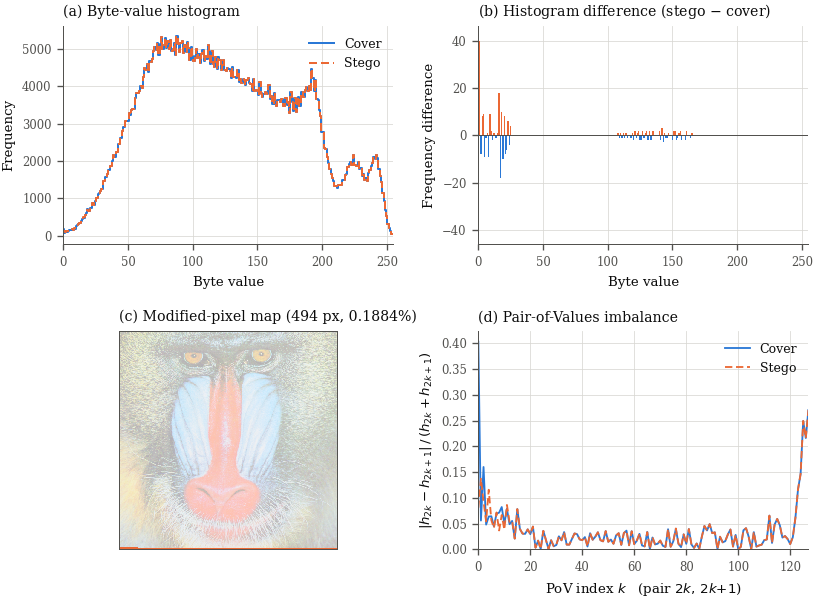

PoV imbalance: cover 0.03676 -> stego 0.03437


In [ ]:
CV_FIG = [c for c in COVERS if "4.2.03" in c][0]
SP_FIG, _, NB_FIG = sisipkan(CV_FIG, PESAN, TS, KEY, out_path="_fig.bmp")
CV_IMG = np.array(Image.open(CV_FIG), dtype=np.uint8)
SG_IMG = np.array(Image.open(SP_FIG), dtype=np.uint8)
CF, SF = CV_IMG.ravel(), SG_IMG.ravel()

n_byte = int(np.count_nonzero(CV_IMG != SG_IMG))
bt = int(np.unpackbits(np.bitwise_xor(CV_IMG, SG_IMG).ravel()).sum())
mse_f = float(np.mean((CV_IMG.astype(float) - SG_IMG.astype(float)) ** 2))
PSNR_FIG = 10 * np.log10(255.0 ** 2 / mse_f)
NPCR_FIG = 100.0 * n_byte / CV_IMG.size

print("Citra   :", CV_FIG)
print("Pesan   : %d karakter -> %d bit" % (N_CHAR, NB_FIG))
print("PSNR    : %.4f dB   (Tabel 1: %.4f)" % (PSNR_FIG, ms("PSNR")[0]))
print("NPCR    : %.6f %%   (Tabel 1: %.6f)" % (NPCR_FIG, ms("NPCR")[0]))
print("bit/byte: %.3f" % (bt / max(n_byte, 1)))
assert abs(bt / max(n_byte, 1) - 1.0) < 0.01, "bukan pola LSB satu bit"
print("\nKonsisten dengan Tabel 1.\n")

# ---------------- Figur 1 ----------------
fig, axes = plt.subplots(2, 2, figsize=(7.0, 5.2))
(a1, a2), (a3, a4) = axes

hc = np.bincount(CF, minlength=256).astype(np.float64)
hs = np.bincount(SF, minlength=256).astype(np.float64)
lv = np.arange(256)

a1.step(lv, hc, where="mid", color=COVER_C, lw=1.2, label="Cover")
a1.step(lv, hs, where="mid", color=STEGO_C, lw=1.2, ls=(0, (4, 2)), label="Stego")
a1.set_xlim(0, 255); a1.legend(loc="upper right")
style(a1, "(a) Byte-value histogram", "Byte value", "Frequency")

dh = hs - hc
a2.bar(lv, dh, color=np.where(dh >= 0, STEGO_C, COVER_C), width=1.0, linewidth=0)
a2.axhline(0, color=INK_SOFT, lw=0.6); a2.set_xlim(0, 255)
lim = max(np.abs(dh).max(), 1) * 1.15
a2.set_ylim(-lim, lim); a2.yaxis.set_major_locator(MaxNLocator(5))
style(a2, "(b) Histogram difference (stego $-$ cover)", "Byte value", "Frequency difference")

delta = np.any(CV_IMG != SG_IMG, axis=2)
npx = int(delta.sum())
a3.imshow(CV_IMG, interpolation="nearest", alpha=0.32)
ys, xs = np.nonzero(delta)
a3.scatter(xs, ys, s=0.4, c=STEGO_C, marker="s", linewidths=0, rasterized=True)
a3.set_xlim(0, CV_IMG.shape[1]); a3.set_ylim(CV_IMG.shape[0], 0)
a3.set_xticks([]); a3.set_yticks([]); a3.grid(False)
for sp_ in a3.spines.values():
    sp_.set_visible(True); sp_.set_color(INK_SOFT)
style(a3, "(c) Modified-pixel map (%s px, %.4f%%)"
      % (format(npx, ","), 100.0 * npx / delta.size))

ec, oc = hc[0::2], hc[1::2]
es, os_ = hs[0::2], hs[1::2]
tc, ts_ = ec + oc, es + os_
keep = (tc > 0) & (ts_ > 0)
ic = np.abs(ec[keep] - oc[keep]) / tc[keep]
is_ = np.abs(es[keep] - os_[keep]) / ts_[keep]
kk = np.arange(128)[keep]
a4.plot(kk, ic, color=COVER_C, lw=1.1, label="Cover")
a4.plot(kk, is_, color=STEGO_C, lw=1.1, ls=(0, (4, 2)), label="Stego")
a4.set_xlim(kk.min(), kk.max()); a4.set_ylim(bottom=0); a4.legend(loc="upper right")
style(a4, "(d) Pair-of-Values imbalance",
      "PoV index $k$   (pair $2k,\,2k{+}1$)",
      r"$|h_{2k}-h_{2k+1}|\,/\,(h_{2k}+h_{2k+1})$")

fig.tight_layout(h_pad=1.6, w_pad=1.8)
fig.savefig("fig_imperceptibility.pdf"); fig.savefig("fig_imperceptibility.png")
plt.show()

POV_C, POV_S = float(ic.mean()), float(is_.mean())
N_PX_FIG = npx
PCT_PX_FIG = 100.0 * npx / delta.size
print("PoV imbalance: cover %.5f -> stego %.5f" % (POV_C, POV_S))


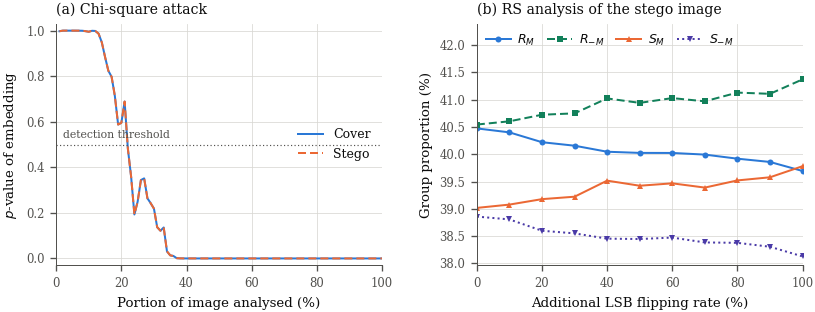

chi-square p-value : cover 0.0000 | stego 0.0000
|R_M - R_-M| at 0% : 0.071


In [ ]:
def chi_sq(flat, n_steps=100):
    tot = flat.size
    fr = np.linspace(0.01, 1.0, n_steps)
    p = np.empty(n_steps)
    for i, f in enumerate(fr):
        seg = flat[: max(int(f * tot), 2)]
        h = np.bincount(seg, minlength=256).astype(np.float64)
        ev, od = h[0::2], h[1::2]
        ex = (ev + od) / 2.0
        ok = ex > 4.0
        if ok.sum() < 2:
            p[i] = 1.0; continue
        stat = np.sum((ev[ok] - ex[ok]) ** 2 / ex[ok])
        df = int(ok.sum()) - 1
        if HAVE_SCIPY:
            p[i] = float(chi2_dist.sf(stat, df))
        else:
            import math
            z = ((stat / df) ** (1 / 3) - (1 - 2 / (9 * df))) / np.sqrt(2 / (9 * df))
            p[i] = 0.5 * math.erfc(z / np.sqrt(2))
    return fr * 100, p


def _flip(x):
    return np.bitwise_xor(x.astype(np.int16), 1)


def _shift(x):
    y = x.astype(np.int16)
    return np.where(y % 2 == 0, y - 1, y + 1)


def _var(g):
    return np.sum(np.abs(np.diff(g.astype(np.int32), axis=1)), axis=1)


def rs_counts(flat, mask=(0, 1, 1, 0)):
    m = np.array(mask, dtype=np.int16); n = m.size
    us = (flat.size // n) * n
    g = flat[:us].reshape(-1, n)
    f0 = _var(g); out = {}
    for nm, mk in (("pos", m), ("neg", -m)):
        a = g.astype(np.int16).copy()
        fl, sh = _flip(g), _shift(g)
        a[:, mk == 1] = fl[:, mk == 1]
        a[:, mk == -1] = sh[:, mk == -1]
        a = np.clip(a, 0, 255)
        f1 = _var(a)
        out["R" + nm] = float(np.sum(f1 > f0) / len(f0) * 100)
        out["S" + nm] = float(np.sum(f1 < f0) / len(f0) * 100)
    return out


fig, (b1, b2) = plt.subplots(1, 2, figsize=(7.0, 2.8))

xc, pc = chi_sq(CF)
xs2, ps2 = chi_sq(SF)
b1.plot(xc, pc, color=COVER_C, lw=1.2, label="Cover")
b1.plot(xs2, ps2, color=STEGO_C, lw=1.2, ls=(0, (4, 2)), label="Stego")
b1.axhline(0.5, color=INK_SOFT, lw=0.7, ls=(0, (1, 2)))
b1.text(2, 0.53, "detection threshold", fontsize=6.5, color=INK_SOFT)
b1.set_xlim(0, 100); b1.set_ylim(-0.03, 1.03); b1.legend(loc="center right")
style(b1, "(a) Chi-square attack", "Portion of image analysed (%)",
      "$p$-value of embedding")

rng = np.random.default_rng(0)
rates = np.linspace(0, 100, 11)
res = {k: [] for k in ("Rpos", "Spos", "Rneg", "Sneg")}
for r in rates:
    if r <= 0:
        t = SF
    else:
        w = SF.copy(); k = int(r / 100.0 * w.size)
        idx = rng.choice(w.size, k, replace=False)
        w[idx] = np.bitwise_xor(w[idx], rng.integers(0, 2, k, dtype=np.uint8))
        t = w
    c = rs_counts(t)
    for key in res:
        res[key].append(c[key])
res = {k: np.array(v) for k, v in res.items()}

for lab, v, col, mk, ls in [
    ("$R_{M}$", res["Rpos"], COVER_C, "o", "-"),
    ("$R_{-M}$", res["Rneg"], ACCENT_C, "s", (0, (4, 2))),
    ("$S_{M}$", res["Spos"], STEGO_C, "^", "-"),
    ("$S_{-M}$", res["Sneg"], VIOLET_C, "v", (0, (1, 1.6))),
]:
    b2.plot(rates, v, color=col, lw=1.2, ls=ls, marker=mk,
            markersize=3.6, markeredgewidth=0, label=lab)

b2.set_xlim(0, 100)
lo, hi = b2.get_ylim()
b2.set_ylim(lo, hi + (hi - lo) * 0.24)
b2.legend(loc="upper left", ncol=4, columnspacing=1.0,
          handlelength=2.0, handletextpad=0.5, borderaxespad=0.3)
style(b2, "(b) RS analysis of the stego image",
      "Additional LSB flipping rate (%)", "Group proportion (%)")

fig.tight_layout(w_pad=2.0)
fig.savefig("fig_steganalysis.pdf"); fig.savefig("fig_steganalysis.png")
plt.show()

P_COVER, P_STEGO = float(pc[-1]), float(ps2[-1])
RS_GAP = float(abs(res["Rpos"][0] - res["Rneg"][0]))
print("chi-square p-value : cover %.4f | stego %.4f" % (P_COVER, P_STEGO))
print("|R_M - R_-M| at 0%% : %.3f" % RS_GAP)


## Sel 11 — Semua tabel LaTeX dan caption

In [ ]:
def sci(x, s=None):
    m, e = ("%.4e" % x).split("e")
    e = int(e)
    if s is None:
        return r"$%s \times 10^{%d}$" % (m, e)
    return r"$(%s \pm %.4f) \times 10^{%d}$" % (m, s / (10.0 ** e), e)


L = []
A = L.append

# ---- Tabel 1 ----
A(r"\begin{table}[htbp]\centering\footnotesize")
A(r"\caption{Image-quality evaluation over %d $%d \times %d$ USC-SIPI cover "
  r"images at a %d-character payload (%.6f~bpp). Values are mean $\pm$ standard "
  r"deviation, computed on the full 24-bit RGB pixel data.}"
  % (len(MET), int(np.sqrt(SIZE / 3)), int(np.sqrt(SIZE / 3)), N_CHAR, BPP))
A(r"\label{tab:quality}")
A(r"\begin{tabular}{llrl}")
A(r"\toprule")
A(r"\textbf{Category} & \textbf{Metric} & \textbf{Value} & \textbf{Ideal / Reference} \\")
A(r"\midrule")
A(r"\multirow{5}{*}{Visual fidelity}")
m, s = ms("PSNR"); A(r"  & PSNR (dB) & $%.4f \pm %.4f$ & $>40$ \\" % (m, s))
for k in ["MSE", "RMSE", "MAE", "RSE"]:
    m, s = ms(k); A(r"  & %s & %s & $\to 0$ \\" % (k, sci(m, s)))
A(r"\midrule")
m, s = ms("NCC")
_e = int(("%e" % s).split("e")[1]) if s > 0 else 0
A(r"Similarity & NCC & $%.9f \pm %.1f \times 10^{%d}$ & $\to 1$ \\"
  % (m, s / (10.0 ** _e), _e))
A(r"\midrule")
A(r"\multirow{2}{*}{Imperceptibility}")
m, s = ms("NPCR"); A(r"  & NPCR (\%%) & $%.6f \pm %.5f$ & $\to 0$ \\" % (m, s))
m, s = ms("UACI"); A(r"  & UACI (\%%) & %s & $\to 0$ \\" % sci(m, s))
A(r"\midrule")
A(r"\multirow{4}{*}{Statistical}")
A(r"  & Entropy (bits) & %.6f & %.6f$^{\dagger}$ \\" % (ms("Hs")[0], ms("Hc")[0]))
for d, a_, b_ in [("H", "cHs", "cHc"), ("V", "cVs", "cVc"), ("D", "cDs", "cDc")]:
    A(r"  & Correlation--%s & %.6f & %.6f$^{\dagger}$ \\"
      % (d, ms(a_)[0], ms(b_)[0]))
A(r"\midrule")
A(r"\multirow{2}{*}{Recovery}")
m, s = ms("BER"); A(r"  & BER (image-level) & %s & $<0.01$ \\" % sci(m, s))
A(r"  & BER (message-level) & $%.1f$ & $0$ \\" % BER_PESAN)
A(r"\bottomrule")
A(r"\multicolumn{4}{p{0.9\linewidth}}{\footnotesize $^{\dagger}$ For entropy and "
  r"correlation the reference is the cover image: the objective is preservation, "
  r"not maximisation. These rows report means without dispersion, as the "
  r"cover--stego difference is the quantity of interest.} \\")
A(r"\end{tabular}\end{table}")
A("")

# ---- Tabel 2 ----
A(r"\begin{table}[htbp]\centering\footnotesize")
A(r"\caption{Effect of payload size, averaged over %d cover images.}" % len(COVERS))
A(r"\label{tab:payload}\begin{tabular}{rrrrrc}")
A(r"\toprule")
A(r"\textbf{Chars} & \textbf{Bits} & \textbf{bpp} & \textbf{PSNR (dB)} & "
  r"\textbf{NPCR (\%)} & \textbf{Recovered} \\")
A(r"\midrule")
for r in PAY:
    A(r"%d & %d & %.6f & $%.4f \pm %.2f$ & %.6f & %s \\"
      % (r["n"], r["bits"], r["bpp"], r["psnr"], r["psd"], r["npcr"],
         r"\checkmark" if r["ok"] else r"$\times$"))
A(r"\bottomrule\end{tabular}\end{table}")
A("")

# ---- Tabel 3 ----
A(r"\begin{table}[htbp]\centering\footnotesize")
A(r"\caption{Comparison against baselines at an identical payload. Ciphertext "
  r"variability is the mean pairwise difference between ciphertexts of the same "
  r"plaintext at five transmission times ($n=%d$ pairs).}" % VAR["npair"])
A(r"\label{tab:baseline}\begin{tabular}{lrrrr}")
A(r"\toprule")
A(r"\textbf{Method} & \textbf{PSNR (dB)} & \textbf{NPCR (\%)} & "
  r"\textbf{Bytes modified} & \textbf{Ciphertext var.\ (\%)} \\")
A(r"\midrule")
for b, v in zip(BASE, ["--", "%.2f" % VAR["sta"], "%.2f" % VAR["dyn"]]):
    A(r"%s & $%.4f \pm %.2f$ & %.6f & %.1f & %s \\"
      % (b["nama"], b["psnr"], b["psd"], b["npcr"], b["nbyte"], v))
A(r"\midrule")
A(r"\textit{Theoretical (uniform bits)} & -- & -- & %.1f & -- \\" % (N_BITS / 2))
A(r"\bottomrule\end{tabular}\end{table}")
A("")

# ---- Tabel 4 ----
A(r"\begin{table}[htbp]\centering\footnotesize")
A(r"\caption{Computational performance, mean over %d runs after %d discarded "
  r"warm-up iterations.}" % (N_RUNS, N_WARMUP))
A(r"\label{tab:timing}\begin{tabular}{lrr}")
A(r"\toprule")
A(r"\textbf{Stage} & \textbf{Mean (ms)} & \textbf{Std.\ dev.\ (ms)} \\")
A(r"\midrule")
for k in TAHAP:
    mm, ss = ST[k]; A(r"%s & %.3f & %.3f \\" % (k, mm, ss))
A(r"\midrule")
mm, ss = ST["Total"]
A(r"\textbf{Total} & \textbf{%.3f} & \textbf{%.3f} \\" % (mm, ss))
A(r"\bottomrule\end{tabular}\end{table}")
A("")

# ---- Caption figur ----
A(r"\begin{figure}[htbp]\centering")
A(r"\includegraphics[width=\linewidth]{fig_imperceptibility.pdf}")
A(r"\caption{Imperceptibility analysis on %s. (a) Byte-value histograms of "
  r"cover and stego images overlap throughout the range. (b) The signed "
  r"histogram difference shows that embedding redistributes counts only between "
  r"adjacent byte values. (c) Spatial distribution of the %s modified pixels "
  r"(%.4f\%% of the image). (d) Pair-of-values imbalance, which the chi-square "
  r"attack exploits, is essentially unchanged (%.5f to %.5f).}"
  % (os.path.basename(COVERS[0]), format(N_PX_FIG, ","), PCT_PX_FIG, POV_C, POV_S))
A(r"\label{fig:imperceptibility}\end{figure}")
A("")
A(r"\begin{figure}[htbp]\centering")
A(r"\includegraphics[width=\linewidth]{fig_steganalysis.pdf}")
A(r"\caption{Steganalysis of the proposed scheme. (a) Chi-square attack: the "
  r"$p$-value of the stego image ($%.4f$) remains indistinguishable from that "
  r"of the cover ($%.4f$) across the entire image. (b) RS analysis: the "
  r"$R_{M}$ and $R_{-M}$ curves differ by only %.3f percentage points at zero "
  r"additional flipping, consistent with a low embedding rate.}"
  % (P_STEGO, P_COVER, RS_GAP))
A(r"\label{fig:steganalysis}\end{figure}")

TEX = "\n".join(L)
with open("tabel_naskah.tex", "w") as f:
    f.write(TEX)
print(TEX)


\begin{table}[htbp]\centering\footnotesize
\caption{Image-quality evaluation over 5 $512 \times 512$ USC-SIPI cover images at a 199-character payload (0.002116~bpp). Values are mean $\pm$ standard deviation, computed on the full 24-bit RGB pixel data.}
\label{tab:quality}
\begin{tabular}{llrl}
\toprule
\textbf{Category} & \textbf{Metric} & \textbf{Value} & \textbf{Ideal / Reference} \\
\midrule
\multirow{5}{*}{Visual fidelity}
  & PSNR (dB) & $77.8575 \pm 0.0699$ & $>40$ \\
  & MSE & $(1.0651 \pm 0.0172) \times 10^{-3}$ & $\to 0$ \\
  & RMSE & $(3.2634 \pm 0.0263) \times 10^{-2}$ & $\to 0$ \\
  & MAE & $(1.0651 \pm 0.0172) \times 10^{-3}$ & $\to 0$ \\
  & RSE & $(5.0346 \pm 1.5184) \times 10^{-8}$ & $\to 0$ \\
\midrule
Similarity & NCC & $0.999999975 \pm 7.6 \times 10^{-9}$ & $\to 1$ \\
\midrule
\multirow{2}{*}{Imperceptibility}
  & NPCR (\%) & $0.106506 \pm 0.00172$ & $\to 0$ \\
  & UACI (\%) & $(4.1767 \pm 0.0674) \times 10^{-4}$ & $\to 0$ \\
\midrule
\multirow{4}{*}{Statistical}
  &

## Sel 12 — Ringkasan angka dan unduh berkas

In [ ]:
print("=" * 62)
print("ANGKA UNTUK ABSTRAK")
print("=" * 62)
print("  PSNR              : %.4f +/- %.4f dB" % ms("PSNR"))
print("  NPCR              : %.6f +/- %.5f %%" % ms("NPCR"))
print("  Payload           : %d karakter (%.6f bpp)" % (N_CHAR, BPP))
print("  BER pesan         : %.1f" % BER_PESAN)
print("  Variabilitas      : %.2f %% (statis %.2f %%)" % (VAR["dyn"], VAR["sta"]))
print("  Entropi byte      : %.4f -> %.4f" % (VAR["Hp"], VAR["Hd"]))
print("  Waktu total       : %.3f +/- %.3f ms" % ST["Total"])
print("  chi-square        : cover %.4f | stego %.4f" % (P_COVER, P_STEGO))
print()
print("=" * 62)
print("EXPERIMENTAL SETUP")
print("=" * 62)
print("  Citra   : %d x %s" % (len(COVERS), ", ".join(os.path.basename(c) for c in COVERS)))
print("  Ukuran  : %d byte piksel per citra" % SIZE)
print("  CPU     : %s" % CPU)
print("  RAM     : %s" % RAM)
print("  Python  : %s | NumPy %s" % (platform.python_version(), np.__version__))
print("  Timestamp tetap : %s | Kunci : %s" % (TS, KEY))
print()

for f in ["fig_imperceptibility.pdf", "fig_steganalysis.pdf", "tabel_naskah.tex"]:
    files.download(f)
print("Tiga berkas diunduh.")


ANGKA UNTUK ABSTRAK
  PSNR              : 77.8575 +/- 0.0699 dB
  NPCR              : 0.106506 +/- 0.00172 %
  Payload           : 199 karakter (0.002116 bpp)
  BER pesan         : 0.0
  Variabilitas      : 60.30 % (statis 0.00 %)
  Entropi byte      : 4.2417 -> 5.8035
  Waktu total       : 3.606 +/- 0.283 ms
  chi-square        : cover 0.0000 | stego 0.0000

EXPERIMENTAL SETUP
  Citra   : 5 x 4.2.01.bmp, 4.2.03.bmp, 4.2.05.bmp, 4.2.07.bmp, house.bmp
  Ukuran  : 786432 byte piksel per citra
  CPU     : Intel(R) Xeon(R) CPU @ 2.20GHz
  RAM     : 13~GB
  Python  : 3.13.15 | NumPy 2.1.3
  Timestamp tetap : [14, 39, 41, 48, 37] | Kunci : [7, 13, 3]



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Tiga berkas diunduh.
